# O1-04 — Gamma Compatibility Pilot

**Owner:** SIN-WEI SU

This notebook creates a pilot dataset for defining a statistically justified
`gamma_incompatible` label.

It follows the supplied RYA simulation logic rather than inventing labels from
group-size ratio, Gamma `shape`, or Gamma `rate`.

The original RYA script simulates 10,000 retest trials for each instance and fits
a Gamma distribution by maximum likelihood. This pilot keeps that structure, but
adds fit-quality metrics that the original CSV did not save.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path(r"C:\AIML Y2 S2\Capstone 1\RYA")

CLASSIFIER_FILE = BASE_DIR / "O1_classifier_inputs_unlabelled.csv"

sys.path.append(str(BASE_DIR))
from gamma_fit_pilot import choose_pilot_instances, run_pilot

print("Classifier file exists:", CLASSIFIER_FILE.exists())


Classifier file exists: True


## 1. Load the clean O1 input dataset

This uses the 54-feature unlabelled table already produced in O1-02.


In [3]:
classifier_ready = pd.read_csv(CLASSIFIER_FILE)

print("Shape:", classifier_ready.shape)
classifier_ready.head()


Shape: (63328, 57)


,exp_code,P_matrix_question,source_file,n_X,n_Y,log_n_X,log_n_Y,group_size_ratio,log_group_size_ratio,X_1,...,P_23,P_24,P_31,P_32,P_33,P_34,P_41,P_42,P_43,P_44
0,orthog_B_3_large_classes_1,cyb1,orthog_B_3_large_classes_feature_output_df.csv,4765,3014,8.469263,8.011355,1.580956,0.458029,0.182371,...,0.215,0.064,0.030,0.066,0.736,0.168,0.023,0.021,0.081,0.875
1,orthog_B_3_large_classes_2,cop1,orthog_B_3_large_classes_feature_output_df.csv,803,2769,6.689599,7.926603,3.448319,1.237887,0.229141,...,0.416,0.127,0.043,0.172,0.666,0.119,0.105,0.078,0.286,0.531
2,orthog_B_3_large_classes_3,phq5,orthog_B_3_large_classes_feature_output_df.csv,4744,1562,8.464847,7.354362,3.037132,1.110914,0.366779,...,0.245,0.037,0.088,0.130,0.642,0.140,0.082,0.041,0.149,0.728
3,orthog_B_3_large_classes_4,ry19,orthog_B_3_large_classes_feature_output_df.csv,2555,858,7.846199,6.755769,2.977855,1.091203,0.457926,...,0.159,0.048,0.013,0.156,0.698,0.133,0.012,0.018,0.128,0.841
4,orthog_B_3_large_classes_5,ry9,orthog_B_3_large_classes_feature_output_df.csv,542,7297,6.297109,8.895356,13.463100,2.599953,0.324723,...,0.276,0.106,0.015,0.120,0.602,0.263,0.018,0.024,0.157,0.801


## 2. Select a representative pilot

We deliberately sample multiple regimes:

- ordinary/balanced cases;
- group-size ratio 10–50;
- ratio 50–100;
- ratio ≥100;
- sparse histograms;
- degenerate one-category histograms;
- non-diagonal-mode P matrices.

These are **sampling strata only**. They are not compatibility labels.


In [5]:
pilot = choose_pilot_instances(
    classifier_ready,
    per_group=25,
    random_state=42
)

print("Pilot size:", len(pilot))
print("\nSelection groups:")
print(pilot["selection_group"].value_counts())

pilot[
    [
        "exp_code", "selection_group",
        "n_X", "n_Y", "group_size_ratio",
        "active_categories_X", "active_categories_Y",
        "degenerate_X", "degenerate_Y",
        "all_rows_diagonal_mode_P"
    ]
].head(20)


Pilot size: 175

Selection groups:
selection_group
regular                25
ratio_10_50            25
ratio_50_100           25
ratio_100_plus         25
sparse                 25
degenerate             25
non_diagonal_mode_P    25
Name: count, dtype: int64


,exp_code,selection_group,n_X,n_Y,group_size_ratio,active_categories_X,active_categories_Y,degenerate_X,degenerate_Y,all_rows_diagonal_mode_P
0,orthog_B_4_11483,regular,253,365,1.442688,4,4,0,0,1
1,orthog_B_1_16054,regular,27,196,7.259259,4,4,0,0,1
2,orthog_B_3_large_classes_818,regular,704,3359,4.771307,4,4,0,0,1
3,orthog_B_4_2965,regular,179,39,4.589744,4,4,0,0,1
4,orthog_B_4_14869,regular,48,465,9.687500,4,4,0,0,1
5,orthog_B_4_10921,regular,57,168,2.947368,4,4,0,0,1
6,orthog_B_4_26733,regular,454,256,1.773438,4,4,0,0,1
7,orthog_B_1_11837,regular,26,56,2.153846,4,4,0,0,1
8,orthog_B_4_19884,regular,121,222,1.834711,4,4,0,0,1
9,orthog_B_1_2347,regular,18,45,2.500000,3,4,0,0,1


In [7]:
pilot_results_test = run_pilot(
    pilot.head(3),
    num_trials=500,
    base_seed=2026
)

print("Test results shape:", pilot_results_test.shape)
pilot_results_test

Completed 1/3
Test results shape: (3, 41)


,exp_code,P_matrix_question,source_file,selection_group,n_X,n_Y,group_size_ratio,active_categories_X,active_categories_Y,degenerate_X,...,q99_emp,q99_gamma,q99_rel_error,tail_cdf_error_95,tail_cdf_error_99,cdf_error_rmse,dhat_mean,dhat_sd,dhat_min,dhat_max
0,orthog_B_4_11483,ry23,orthog_B_4_feature_output_df.csv,regular,253,365,1.442688,4,4,0,...,0.287246,0.277893,0.032563,0.001619,0.002948,0.008161,0.145816,0.047586,0.045199,0.325771
1,orthog_B_1_16054,ry11,orthog_B_1_feature_output_df.csv,regular,27,196,7.259259,4,4,0,...,0.393857,0.420949,0.068786,0.007869,0.004966,0.008667,0.141589,0.087318,0.006849,0.653290
2,orthog_B_3_large_classes_818,tru2,orthog_B_3_large_classes_feature_output_df.csv,regular,704,3359,4.771307,4,4,0,...,0.079932,0.086085,0.076987,0.010659,0.008829,0.013103,0.041094,0.014907,0.002067,0.087232


## 3. Run the RYA-style 10,000-trial simulation

This may take several minutes depending on your laptop.

Start with `num_trials=2000` only if you want a quick code check.
For actual pilot metrics, rerun with `num_trials=10000` to match the RYA methodology.


In [9]:
pilot_results = run_pilot(
    pilot,
    num_trials=10_000,
    base_seed=2026
)

print("Results shape:", pilot_results.shape)
pilot_results.head()


Completed 1/175
Completed 10/175
Completed 20/175
Completed 30/175
Completed 40/175
Completed 50/175
Completed 60/175
Completed 70/175
Completed 80/175
Completed 90/175
Completed 100/175
Completed 110/175
Completed 120/175
Completed 130/175
Completed 140/175
Completed 150/175
Completed 160/175
Completed 170/175
Results shape: (175, 41)


,exp_code,P_matrix_question,source_file,selection_group,n_X,n_Y,group_size_ratio,active_categories_X,active_categories_Y,degenerate_X,...,q99_emp,q99_gamma,q99_rel_error,tail_cdf_error_95,tail_cdf_error_99,cdf_error_rmse,dhat_mean,dhat_sd,dhat_min,dhat_max
0,orthog_B_4_11483,ry23,orthog_B_4_feature_output_df.csv,regular,253,365,1.442688,4,4,0,...,0.280926,0.286546,0.020003,0.003755,0.002163,0.004188,0.148206,0.048640,0.013908,0.394925
1,orthog_B_1_16054,ry11,orthog_B_1_feature_output_df.csv,regular,27,196,7.259259,4,4,0,...,0.418097,0.463656,0.108967,0.009805,0.007783,0.012365,0.143884,0.092505,0.000242,0.729862
2,orthog_B_3_large_classes_818,tru2,orthog_B_3_large_classes_feature_output_df.csv,regular,704,3359,4.771307,4,4,0,...,0.083672,0.086201,0.030221,0.002234,0.003060,0.002646,0.041672,0.015378,0.004332,0.132384
3,orthog_B_4_2965,ry12,orthog_B_4_feature_output_df.csv,regular,179,39,4.589744,4,4,0,...,0.278380,0.302625,0.087096,0.003765,0.005710,0.007635,0.089045,0.061626,0.000151,0.416254
4,orthog_B_4_14869,ry4,orthog_B_4_feature_output_df.csv,regular,48,465,9.687500,4,4,0,...,0.477663,0.505441,0.058155,0.013847,0.005286,0.014419,0.212828,0.093746,0.001332,0.728889


In [59]:
## 4. Validate and save the pilot simulation results


In [11]:
print("Fit failures:")
print(pilot_results["fit_failed"].value_counts(dropna=False))

print("\nValid trial counts:")
print(pilot_results["valid_trials"].describe())

print("\nAny missing values in fit metrics?")
print(pilot_results.isna().sum().sort_values(ascending=False).head(15))

Fit failures:
fit_failed
0    175
Name: count, dtype: int64

Valid trial counts:
count      175.000000
mean      9999.988571
std          0.106597
min       9999.000000
25%      10000.000000
50%      10000.000000
75%      10000.000000
max      10000.000000
Name: valid_trials, dtype: float64

Any missing values in fit metrics?
exp_code             0
bic_weibull          0
q50_emp              0
q50_gamma            0
q50_rel_error        0
q75_rel_error        0
q90_rel_error        0
q95_emp              0
q95_gamma            0
q95_rel_error        0
q99_emp              0
q99_gamma            0
q99_rel_error        0
tail_cdf_error_95    0
tail_cdf_error_99    0
dtype: int64


In [61]:
## 5. metric summary onward.

In [13]:
metric_cols = [
    "ks_stat",
    "q95_rel_error",
    "tail_cdf_error_95",
    "q99_rel_error",
    "cdf_error_rmse",
    "delta_bic_gamma_minus_weibull"
]

pilot_results[metric_cols].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
ks_stat,175.0,0.048327,0.041933,0.005972,0.035219,0.058046,0.105305,0.125471,0.194798,0.242905
q95_rel_error,175.0,0.058940,0.050594,0.001014,0.043706,0.078555,0.126410,0.163117,0.228171,0.299896
tail_cdf_error_95,175.0,0.014900,0.014217,0.000372,0.010760,0.017901,0.035362,0.041195,0.064811,0.079500
q99_rel_error,175.0,0.125410,0.096036,0.000526,0.097962,0.169869,0.264877,0.311302,0.384900,0.487480
cdf_error_rmse,175.0,0.019997,0.016143,0.001710,0.014395,0.026508,0.042604,0.056160,0.075184,0.084925
delta_bic_gamma_minus_weibull,175.0,164.064727,545.375481,-1216.201307,83.532371,332.773870,820.622566,1158.516417,1952.115116,2180.985097


In [63]:
## 6. Inspect the worst Gamma-fit cases

In [15]:
worst_q95 = pilot_results.nlargest(
    20,
    "q95_rel_error"
)[
    [
        "exp_code",
        "P_matrix_question",
        "selection_group",
        "n_X",
        "n_Y",
        "group_size_ratio",
        "active_categories_X",
        "active_categories_Y",
        "degenerate_X",
        "degenerate_Y",
        "all_rows_diagonal_mode_P",
        "ks_stat",
        "q95_rel_error",
        "tail_cdf_error_95",
        "q99_rel_error",
        "cdf_error_rmse",
        "delta_bic_gamma_minus_weibull"
    ]
]

worst_q95

,exp_code,P_matrix_question,selection_group,n_X,n_Y,group_size_ratio,active_categories_X,active_categories_Y,degenerate_X,degenerate_Y,all_rows_diagonal_mode_P,ks_stat,q95_rel_error,tail_cdf_error_95,q99_rel_error,cdf_error_rmse,delta_bic_gamma_minus_weibull
76,orthog_B_1_25825,ry31,ratio_100_plus,8,905,113.125000,3,4,0,0,1,0.242905,0.299896,0.079500,0.379695,0.075157,1938.637376
78,orthog_B_4_25676,cop4,ratio_100_plus,6,687,114.500000,3,4,0,0,1,0.216103,0.250421,0.062699,0.487480,0.075263,1680.989210
94,orthog_B_1_4238,ry22,ratio_100_plus,5,577,115.400000,2,4,0,0,1,0.170997,0.220353,0.067889,0.362988,0.084925,1905.878786
130,orthog_B_1_5298,ry7,degenerate,469,5,93.800000,4,1,0,1,1,0.115104,0.191620,0.063730,0.373538,0.067244,1631.721975
77,orthog_B_4_1119,ry15,ratio_100_plus,6,700,116.666667,4,4,0,0,1,0.080843,0.189807,0.036723,0.010659,0.031592,128.032431
81,orthog_B_4_21546,sun11,ratio_100_plus,653,6,108.833333,4,3,0,0,1,0.146925,0.185544,0.040341,0.165523,0.058114,-1152.122050
57,orthog_B_1_22100,ry20,ratio_50_100,7,359,51.285714,3,4,0,0,1,0.104276,0.168557,0.038105,0.167851,0.039823,522.722684
120,orthog_B_1_2470,tru2,sparse,5,809,161.800000,2,4,0,0,1,0.113692,0.167347,0.043186,0.227623,0.045509,910.283580
87,orthog_B_4_18512,ph3,ratio_100_plus,846,5,169.200000,4,3,0,0,1,0.130598,0.167284,0.038806,0.399714,0.036792,983.779099
138,orthog_B_4_443,ry21,degenerate,31,5,6.200000,4,1,0,1,1,0.110289,0.161332,0.063109,0.301446,0.059854,2180.985097


In [65]:
## 7. Compare fit quality across pilot regimes

In [17]:
group_summary = pilot_results.groupby(
    "selection_group"
)[
    [
        "ks_stat",
        "q95_rel_error",
        "tail_cdf_error_95",
        "q99_rel_error",
        "cdf_error_rmse"
    ]
].agg(["count", "median", "mean", "max"])

group_summary

ks_stat                               q95_rel_error  \
                      count    median      mean       max         count   
selection_group                                                           
degenerate               25  0.056161  0.063815  0.123274            25   
non_diagonal_mode_P      25  0.017641  0.021104  0.053688            25   
ratio_100_plus           25  0.085481  0.099616  0.242905            25   
ratio_10_50              25  0.023596  0.025769  0.055877            25   
ratio_50_100             25  0.053458  0.058588  0.118411            25   
regular                  25  0.016279  0.016277  0.026982            25   
sparse                   25  0.042121  0.053120  0.186052            25   

                                                  tail_cdf_error_95            \
                       median      mean       max             count    median   
selection_group                                                                 
degenerate           0.077978  0.086615  0.191620                25  0.020530   
non_diagonal_mode_P  0.028187  0.032693  0.089135                25  0.006183   
ratio_100_plus       0.071451  0.099704  0.299896                25  0.017736   
ratio_10_50          0.029583  0.036937  0.085769                25  0.008790   
ratio_50_100         0.062770  0.065847  0.168557                25  0.014098   
regular              0.015927  0.021851  0.046939                25  0.005566   
sparse               0.062274  0.068933  0.167347                25  0.014464   

                                        q99_rel_error                      \
                         mean       max         count    median      mean   
selection_group                                                             
degenerate           0.025194  0.063730            25  0.212935  0.213184   
non_diagonal_mode_P  0.006841  0.017874            25  0.070881  0.077136   
ratio_100_plus       0.024184  0.079500            25  0.161444  0.186878   
ratio_10_50          0.009607  0.020429            25  0.081944  0.081011   
ratio_50_100         0.015837  0.038105            25  0.136512  0.132702   
regular              0.005853  0.013847            25  0.044398  0.050478   
sparse               0.016784  0.054407            25  0.140963  0.136484   

                              cdf_error_rmse                                
                          max          count    median      mean       max  
selection_group                                                             
degenerate           0.373538             25  0.027264  0.031255  0.067244  
non_diagonal_mode_P  0.201365             25  0.007480  0.009320  0.022081  
ratio_100_plus       0.487480             25  0.028873  0.034949  0.084925  
ratio_10_50          0.214029             25  0.011361  0.012662  0.027988  
ratio_50_100         0.309216             25  0.021502  0.023167  0.058404  
regular              0.108967             25  0.006675  0.007338  0.014419  
sparse               0.312118             25  0.018799  0.021290  0.047092

In [67]:
## 8. Visual validation — clearly good vs clearly poor fits

In [21]:
# Select 3 worst cases by 95th-percentile relative error
worst_indices = (
    pilot_results["q95_rel_error"]
    .nlargest(3)
    .index
    .tolist()
)

# Select 3 representative regular cases close to the regular-group median
regular_results = pilot_results[
    pilot_results["selection_group"] == "regular"
].copy()

regular_median_q95 = regular_results["q95_rel_error"].median()

regular_results["distance_from_regular_median"] = (
    regular_results["q95_rel_error"] - regular_median_q95
).abs()

regular_indices = (
    regular_results
    .nsmallest(3, "distance_from_regular_median")
    .index
    .tolist()
)

comparison_indices = worst_indices + regular_indices

print("Worst-case indices:", worst_indices)
print("Representative regular indices:", regular_indices)

pilot_results.loc[
    comparison_indices,
    [
        "exp_code",
        "selection_group",
        "n_X",
        "n_Y",
        "group_size_ratio",
        "ks_stat",
        "q95_rel_error",
        "tail_cdf_error_95",
        "q99_rel_error"
    ]
]

Worst-case indices: [76, 78, 94]
Representative regular indices: [6, 14, 11]


,exp_code,selection_group,n_X,n_Y,group_size_ratio,ks_stat,q95_rel_error,tail_cdf_error_95,q99_rel_error
76,orthog_B_1_25825,ratio_100_plus,8,905,113.125000,0.242905,0.299896,0.079500,0.379695
78,orthog_B_4_25676,ratio_100_plus,6,687,114.500000,0.216103,0.250421,0.062699,0.487480
94,orthog_B_1_4238,ratio_100_plus,5,577,115.400000,0.170997,0.220353,0.067889,0.362988
6,orthog_B_4_26733,regular,454,256,1.773438,0.010980,0.015927,0.005485,0.037920
14,orthog_B_1_11615,regular,142,467,3.288732,0.019602,0.015790,0.005753,0.033146
11,orthog_B_4_15652,regular,187,940,5.026738,0.010962,0.014472,0.004717,0.024485


In [23]:
from scipy import stats

from gamma_fit_pilot import (
    simulate_d_hat,
    row_to_p_matrix
)

In [27]:
def plot_gamma_fit_case(
    pilot_index,
    num_trials=10_000,
    base_seed=2026
):
    row = pilot.loc[pilot_index]
    result = pilot_results.loc[pilot_index]

    X = [row[f"X_{i}"] for i in range(1, 5)]
    Y = [row[f"Y_{i}"] for i in range(1, 5)]
    P = row_to_p_matrix(row)

    # Use the same seed logic as the original pilot run
    d_hat = simulate_d_hat(
        X_prop=X,
        Y_prop=Y,
        n_x=row["n_X"],
        n_y=row["n_Y"],
        P=P,
        num_trials=num_trials,
        seed=base_seed + pilot_index,
        scale_true=True
    )

    d_hat = d_hat[
        np.isfinite(d_hat) & (d_hat > 0)
    ]

    # Refit Gamma
    gamma_shape, _, gamma_scale = stats.gamma.fit(
        d_hat,
        floc=0
    )

    # Empirical and Gamma 95th percentiles
    q95_emp = np.quantile(d_hat, 0.95)

    q95_gamma = stats.gamma.ppf(
        0.95,
        gamma_shape,
        loc=0,
        scale=gamma_scale
    )

    # X-axis for Gamma density
    x_grid = np.linspace(
        d_hat.min(),
        np.quantile(d_hat, 0.999),
        500
    )

    gamma_pdf = stats.gamma.pdf(
        x_grid,
        gamma_shape,
        loc=0,
        scale=gamma_scale
    )

    plt.figure(figsize=(9, 5))

    plt.hist(
        d_hat,
        bins=60,
        density=True,
        alpha=0.5,
        label="Empirical simulated d_hat"
    )

    plt.plot(
        x_grid,
        gamma_pdf,
        linewidth=2,
        label="Fitted Gamma"
    )

    plt.axvline(
        q95_emp,
        linestyle="--",
        linewidth=2,
        label="Empirical 95th percentile"
    )

    plt.axvline(
        q95_gamma,
        linestyle=":",
        linewidth=2,
        label="Gamma 95th percentile"
    )

    plt.title(
        f"{result['exp_code']} | "
        f"{result['selection_group']} | "
        f"ratio={result['group_size_ratio']:.1f}\n"
        f"q95 error={result['q95_rel_error']:.1%}, "
        f"KS={result['ks_stat']:.3f}"
    )

    plt.xlabel("d_hat")
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

=== WORST GAMMA FITS ===


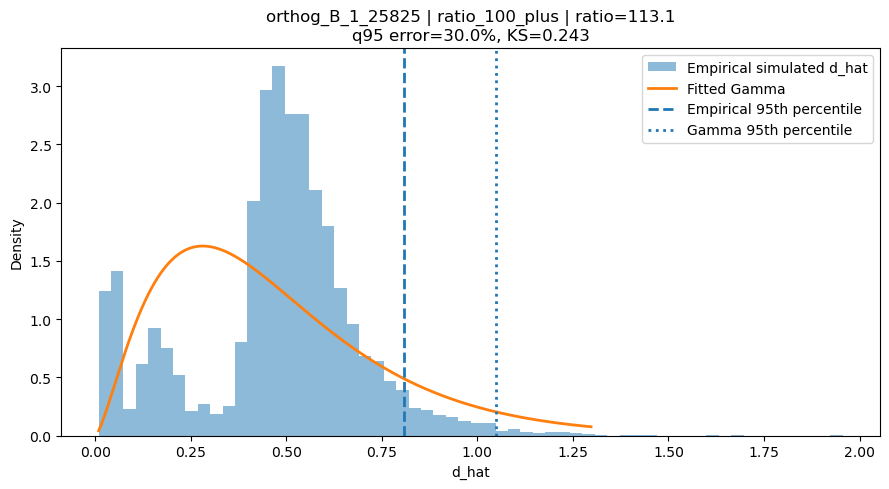

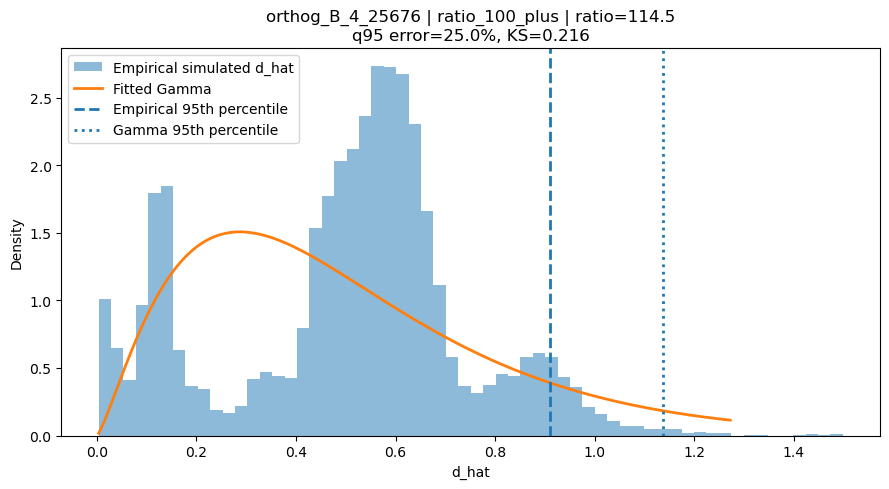

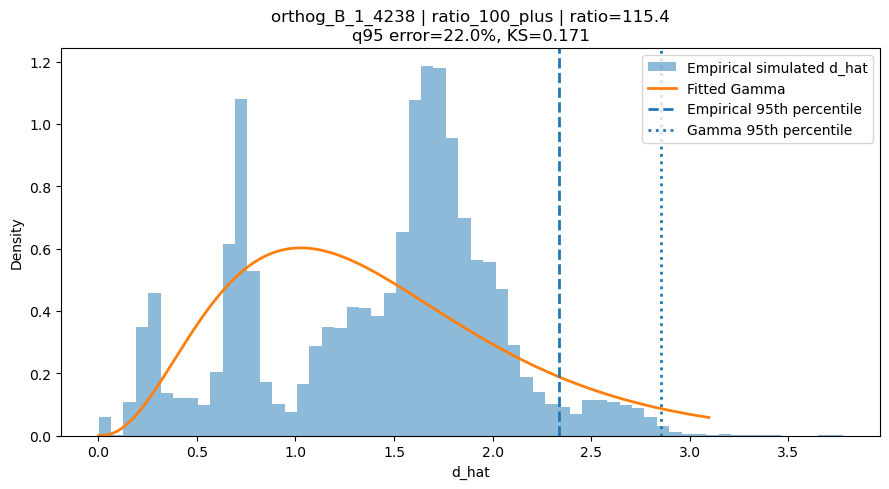

In [29]:
print("=== WORST GAMMA FITS ===")

for idx in worst_indices:
    plot_gamma_fit_case(idx)

=== REPRESENTATIVE REGULAR CASES ===


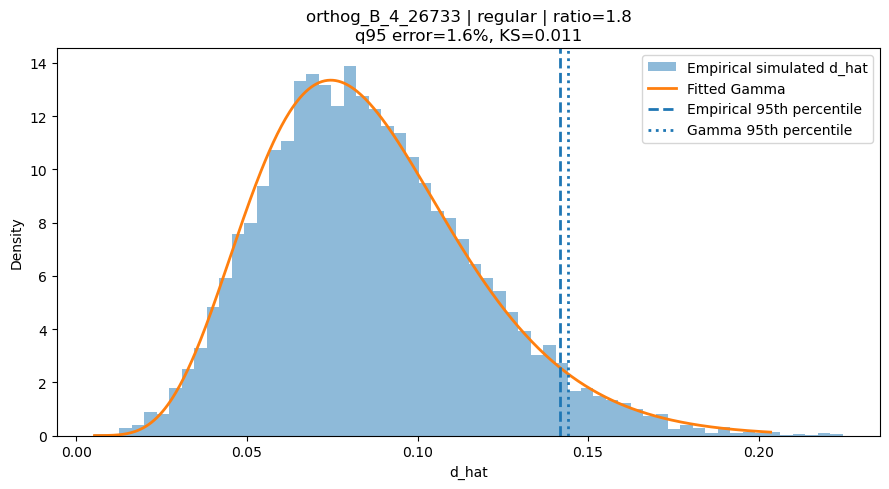

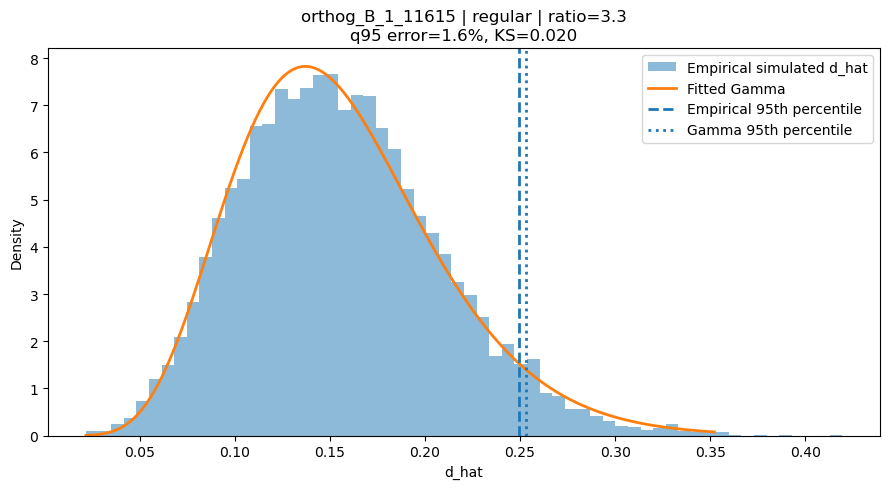

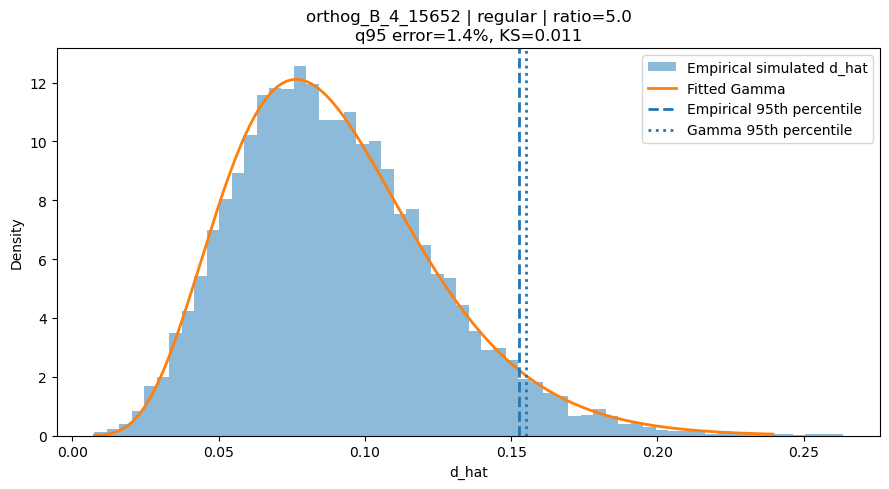

In [31]:
print("=== REPRESENTATIVE REGULAR CASES ===")

for idx in regular_indices:
    plot_gamma_fit_case(idx)

In [69]:
## 9. Threshold sensitivity analysis

In [33]:
threshold_results = []

q95_thresholds = [0.05, 0.10, 0.15]
ks_thresholds = [0.05, 0.10, 0.15]

for q95_t in q95_thresholds:
    for ks_t in ks_thresholds:

        incompatible = (
            (pilot_results["q95_rel_error"] > q95_t)
            | (pilot_results["ks_stat"] > ks_t)
        )

        threshold_results.append({
            "q95_threshold": q95_t,
            "ks_threshold": ks_t,
            "n_incompatible": int(incompatible.sum()),
            "pct_incompatible": incompatible.mean() * 100,
            "n_compatible": int((~incompatible).sum())
        })

threshold_table = pd.DataFrame(threshold_results)

threshold_table

,q95_threshold,ks_threshold,n_incompatible,pct_incompatible,n_compatible
0,0.05,0.05,86,49.142857,89
1,0.05,0.10,78,44.571429,97
2,0.05,0.15,78,44.571429,97
3,0.10,0.05,61,34.857143,114
4,0.10,0.10,35,20.000000,140
5,0.10,0.15,27,15.428571,148
6,0.15,0.05,60,34.285714,115
7,0.15,0.10,26,14.857143,149
8,0.15,0.15,16,9.142857,159


In [35]:
for q95_t in q95_thresholds:
    for ks_t in ks_thresholds:

        temp = pilot_results.copy()

        temp["gamma_incompatible_temp"] = (
            (temp["q95_rel_error"] > q95_t)
            | (temp["ks_stat"] > ks_t)
        ).astype(int)

        print(
            f"\nq95 > {q95_t:.0%} OR KS > {ks_t:.2f}"
        )

        print(
            pd.crosstab(
                temp["selection_group"],
                temp["gamma_incompatible_temp"]
            )
        )


q95 > 5% OR KS > 0.05
gamma_incompatible_temp   0   1
selection_group                
degenerate                3  22
non_diagonal_mode_P      21   4
ratio_100_plus            7  18
ratio_10_50              18   7
ratio_50_100              7  18
regular                  25   0
sparse                    8  17

q95 > 5% OR KS > 0.10
gamma_incompatible_temp   0   1
selection_group                
degenerate                5  20
non_diagonal_mode_P      21   4
ratio_100_plus            9  16
ratio_10_50              18   7
ratio_50_100             10  15
regular                  25   0
sparse                    9  16

q95 > 5% OR KS > 0.15
gamma_incompatible_temp   0   1
selection_group                
degenerate                5  20
non_diagonal_mode_P      21   4
ratio_100_plus            9  16
ratio_10_50              18   7
ratio_50_100             10  15
regular                  25   0
sparse                    9  16

q95 > 10% OR KS > 0.05
gamma_incompatible_temp   0   1
selection_g

In [71]:
## 10. Provisional binary compatibility label v1

In [37]:
pilot_results["gamma_incompatible_v1"] = (
    (pilot_results["q95_rel_error"] > 0.10)
    | (pilot_results["ks_stat"] > 0.10)
).astype(int)

print(
    pilot_results["gamma_incompatible_v1"]
    .value_counts()
)

print("\nPercentage:")
print(
    pilot_results["gamma_incompatible_v1"]
    .value_counts(normalize=True) * 100
)

gamma_incompatible_v1
0    140
1     35
Name: count, dtype: int64

Percentage:
gamma_incompatible_v1
0    80.0
1    20.0
Name: proportion, dtype: float64


In [39]:
LABELLED_PILOT_FILE = (
    BASE_DIR / "O1_gamma_fit_pilot_labelled_v1.csv"
)

pilot_results.to_csv(
    LABELLED_PILOT_FILE,
    index=False
)

print("Saved:")
print(LABELLED_PILOT_FILE)

Saved:
C:\AIML Y2 S2\Capstone 1\RYA\O1_gamma_fit_pilot_labelled_v1.csv


In [73]:
## 11. Boundary-case analysis

In [41]:
boundary_cases = pilot_results[
    (
        pilot_results["q95_rel_error"].between(0.08, 0.12)
    )
    |
    (
        pilot_results["ks_stat"].between(0.08, 0.12)
    )
].copy()

boundary_cases = boundary_cases[
    [
        "exp_code",
        "selection_group",
        "n_X",
        "n_Y",
        "group_size_ratio",
        "ks_stat",
        "q95_rel_error",
        "tail_cdf_error_95",
        "q99_rel_error",
        "gamma_incompatible_v1"
    ]
].sort_values(
    ["gamma_incompatible_v1", "q95_rel_error", "ks_stat"]
)

print("Boundary cases:", len(boundary_cases))
boundary_cases

Boundary cases: 39


,exp_code,selection_group,n_X,n_Y,group_size_ratio,ks_stat,q95_rel_error,tail_cdf_error_95,q99_rel_error,gamma_incompatible_v1
95,orthog_B_1_1118,ratio_100_plus,519,5,103.800000,0.094546,0.030520,0.007172,0.063836,0
141,orthog_B_1_13832,degenerate,5,995,199.000000,0.081481,0.032317,0.008022,0.290005,0
80,orthog_B_1_29065,ratio_100_plus,7,740,105.714286,0.090406,0.062677,0.012223,0.161444,0
96,orthog_B_4_399,ratio_100_plus,8,884,110.500000,0.085481,0.071257,0.014592,0.129435,0
146,orthog_B_4_15638,degenerate,9,377,41.888889,0.051589,0.080412,0.027559,0.182332,0
58,orthog_B_4_16597,ratio_50_100,975,12,81.250000,0.050046,0.081663,0.017929,0.178638,0
147,orthog_B_1_9877,degenerate,35,5,7.000000,0.052814,0.083682,0.023232,0.241455,0
116,orthog_B_4_19141,sparse,380,11,34.545455,0.039270,0.084568,0.024490,0.136237,0
43,orthog_B_1_6778,ratio_10_50,11,160,14.545455,0.043362,0.085769,0.020429,0.175388,0
90,orthog_B_4_17636,ratio_100_plus,921,6,153.500000,0.073096,0.086217,0.020771,0.280689,0


=== JUST BELOW BOUNDARY ===


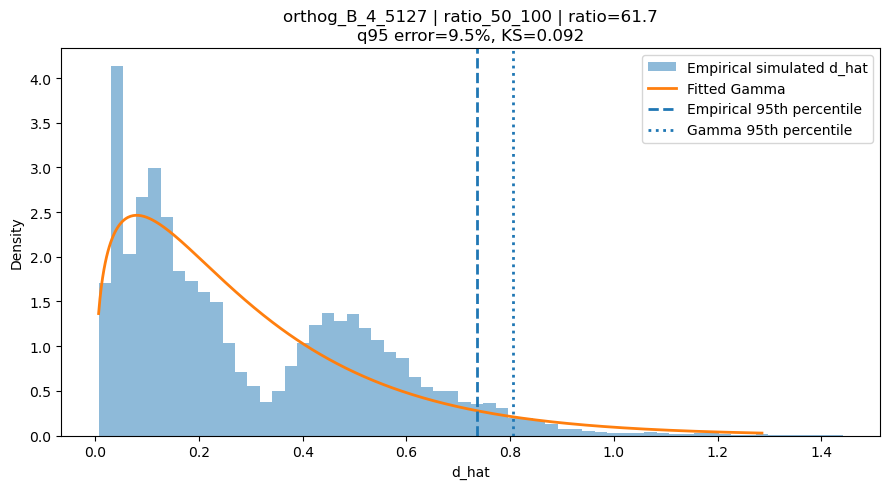

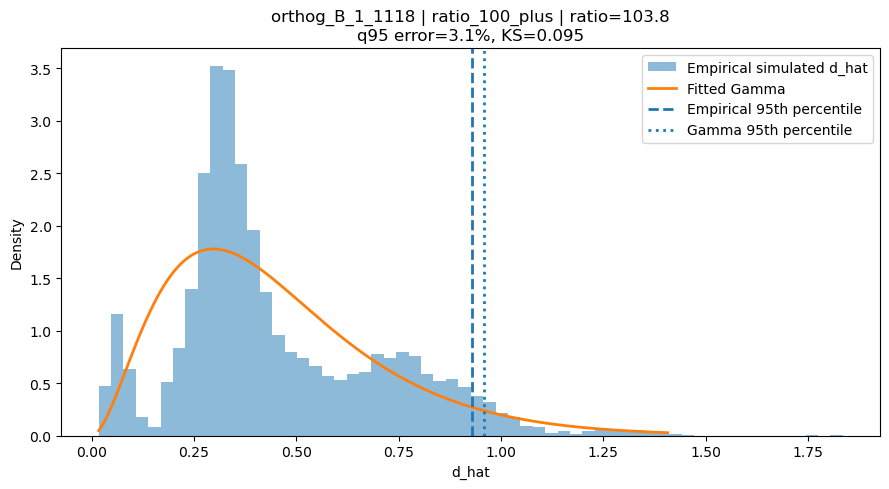

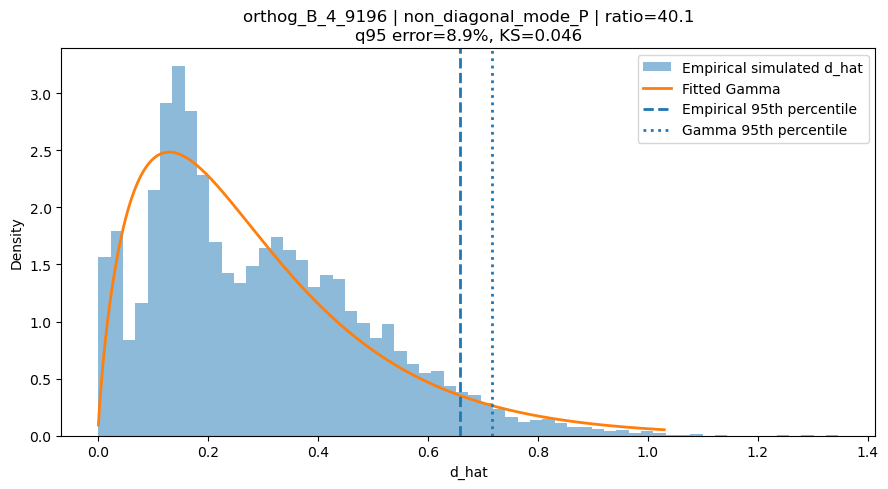

=== JUST ABOVE BOUNDARY ===


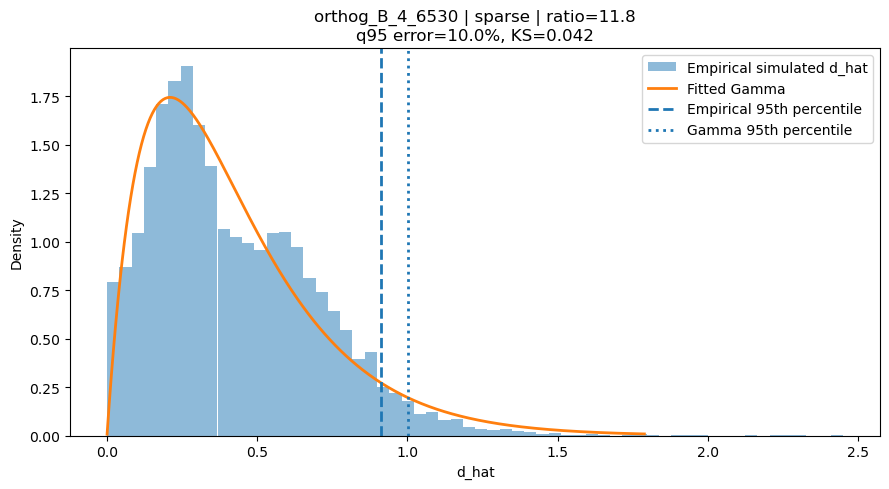

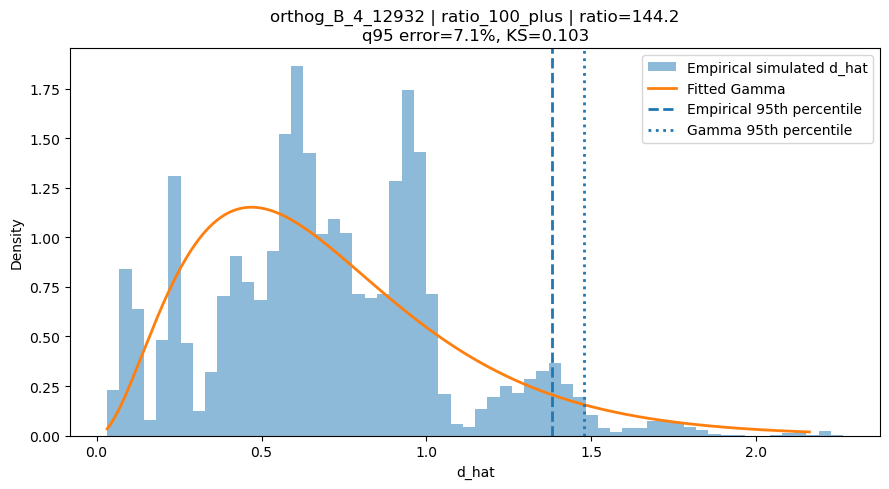

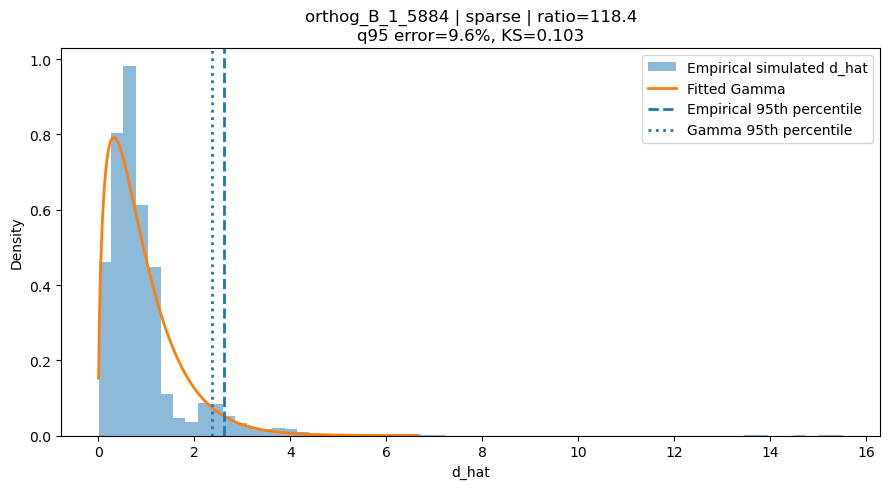

In [43]:
below_boundary_indices = [56, 95, 164]
above_boundary_indices = [123, 93, 108]

print("=== JUST BELOW BOUNDARY ===")
for idx in below_boundary_indices:
    plot_gamma_fit_case(idx)

print("=== JUST ABOVE BOUNDARY ===")
for idx in above_boundary_indices:
    plot_gamma_fit_case(idx)

In [75]:
## 12. Three-zone compatibility scheme v1

In [45]:
def compatibility_zone(row):
    if (
        row["q95_rel_error"] <= 0.05
        and row["ks_stat"] <= 0.05
    ):
        return "compatible"

    elif (
        row["q95_rel_error"] > 0.10
        or row["ks_stat"] > 0.10
    ):
        return "incompatible"

    else:
        return "ambiguous"


pilot_results["compatibility_zone_v1"] = (
    pilot_results.apply(
        compatibility_zone,
        axis=1
    )
)

print(
    pilot_results["compatibility_zone_v1"]
    .value_counts()
)

print("\nPercentage:")
print(
    pilot_results["compatibility_zone_v1"]
    .value_counts(normalize=True) * 100
)

compatibility_zone_v1
compatible      89
ambiguous       51
incompatible    35
Name: count, dtype: int64

Percentage:
compatibility_zone_v1
compatible      50.857143
ambiguous       29.142857
incompatible    20.000000
Name: proportion, dtype: float64


In [47]:
pd.crosstab(
    pilot_results["selection_group"],
    pilot_results["compatibility_zone_v1"]
)

compatibility_zone_v1,ambiguous,compatible,incompatible
selection_group,,,
degenerate,12,3,10
non_diagonal_mode_P,4,21,0
ratio_100_plus,6,7,12
ratio_10_50,7,18,0
ratio_50_100,11,7,7
regular,0,25,0
sparse,11,8,6


In [77]:
## 13. Save the final zoned pilot dataset

In [49]:
ZONE_FILE = (
    BASE_DIR / "O1_gamma_fit_pilot_zones_v1.csv"
)

pilot_results.to_csv(
    ZONE_FILE,
    index=False
)

print("Saved:")
print(ZONE_FILE)

Saved:
C:\AIML Y2 S2\Capstone 1\RYA\O1_gamma_fit_pilot_zones_v1.csv
